# WSBM `wsbm_best_match_*.csv` Visualization Analysis

This version uses the same summary/evaluation pipeline as `new_cluster_similarity_test copy 4.ipynb`.

Key conventions:
- high/low labels are based on per-run `f1_score`;
- `high_frequency` and `low_frequency` are divided by each type's observed `n_runs`, matching the old pipeline;
- summary is sorted by `high_runs`, then `mean_score`, then `gt_size`;
- robust/always/occasionally/mixed tables are saved with the same naming logic as the old pipeline;
- an extra large-region **portion** analysis is added so regions with more GT types, such as Optic Lobe, are normalized by their total number of types.


In [16]:
import os
import glob
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="ticks", context="talk", font_scale=0.9)
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


## 1. Config

In [17]:
CSV_DIR = Path(".")
FILE_PATTERN = "wsbm_best_match_*.csv"

OUT_DIR = Path("wsbm_type_summary_results")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

METRIC = "f1_score"

HIGH_THRESHOLD = 0.50
LOW_THRESHOLD = 0.30

# Same as old pipeline: keep all GT sizes unless you explicitly change this.
MIN_GT_SIZE = 5

# Same as old pipeline: robust means high/low in at least this many runs.
ROBUST_HIGH_RUNS = 8
ROBUST_LOW_RUNS = 8

TOP_N = 40
DPI = 300


## 2. Load all WSBM best-match CSV files

In [18]:
def extract_run_id(path: Path) -> int:
    # Example filename: wsbm_best_match_0.csv
    return int(path.stem.split("_")[-1])

files = sorted(CSV_DIR.glob(FILE_PATTERN), key=extract_run_id)

if len(files) == 0:
    raise FileNotFoundError(
        f"No files matched {CSV_DIR / FILE_PATTERN}. "
        "Please check CSV_DIR and FILE_PATTERN."
    )

all_dfs = []
for f in files:
    run_id = extract_run_id(f)
    tmp = pd.read_csv(f)
    tmp["run"] = run_id
    tmp["source_file"] = f.name
    all_dfs.append(tmp)

all_df = pd.concat(all_dfs, ignore_index=True)

print(f"Loaded {len(files)} files")
print(f"Total rows: {len(all_df)}")
print("Files:")
for f in files:
    print("  ", f.name)

display(all_df.head())
display(all_df.describe(include="all").T)


Loaded 10 files
Total rows: 7348
Files:
   wsbm_best_match_0.csv
   wsbm_best_match_1.csv
   wsbm_best_match_2.csv
   wsbm_best_match_3.csv
   wsbm_best_match_4.csv
   wsbm_best_match_5.csv
   wsbm_best_match_6.csv
   wsbm_best_match_7.csv
   wsbm_best_match_8.csv
   wsbm_best_match_9.csv


,rank,pred_cluster,gt_type,gt_name,correct_cells,cluster_size,purity,gt_size,recall,f1_score,run,source_file
0,1,1002,415,SIP017,1,1,1.0,1,1.0,1.0,0,wsbm_best_match_0.csv
1,2,801,454,CB2580,1,1,1.0,1,1.0,1.0,0,wsbm_best_match_0.csv
2,3,760,421,MTe10,8,8,1.0,8,1.0,1.0,0,wsbm_best_match_0.csv
3,4,725,274,mALD1,2,2,1.0,2,1.0,1.0,0,wsbm_best_match_0.csv
4,5,938,221,PLP021,1,1,1.0,1,1.0,1.0,0,wsbm_best_match_0.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rank,7348.0,NaN,NaN,NaN,367.945291,212.210952,1.0,184.0,368.0,552.0,743.0
pred_cluster,7348.0,NaN,NaN,NaN,540.423108,312.899691,0.0,271.0,536.0,812.0,1085.0
gt_type,7348.0,NaN,NaN,NaN,367.036881,212.365132,0.0,183.0,367.0,551.0,742.0
gt_name,7348,743,LTe25,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
correct_cells,7348.0,NaN,NaN,NaN,28.164943,92.511253,0.0,0.0,0.0,17.25,2290.0
cluster_size,7348.0,NaN,NaN,NaN,129.037425,146.83192,1.0,45.0,95.0,174.0,2311.0
purity,7348.0,NaN,NaN,NaN,0.242445,0.343182,0.0,0.0,0.0,0.407529,1.0
gt_size,7348.0,NaN,NaN,NaN,129.418617,418.859387,1.0,2.0,4.0,55.0,7240.0
recall,7348.0,NaN,NaN,NaN,0.230332,0.323841,0.0,0.0,0.0,0.35565,1.0
f1_score,7348.0,NaN,NaN,NaN,0.18709,0.251872,0.0,0.0,0.0,0.332917,1.0


## 3. Validate columns and create high / low labels

In [19]:
required_cols = {"gt_type", "gt_name", "gt_size", METRIC}
missing = required_cols - set(all_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(all_df.columns)}")

optional_numeric_cols = ["purity", "recall", "f1_score", "correct_cells", "cluster_size"]
for col in optional_numeric_cols:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors="coerce")

df = all_df.copy()

df["gt_size"] = pd.to_numeric(df["gt_size"], errors="coerce")
df[METRIC] = pd.to_numeric(df[METRIC], errors="coerce")

# Same as old pipeline.
df_filtered = df[df["gt_size"] >= MIN_GT_SIZE].copy()

print(f"Rows after gt_size >= {MIN_GT_SIZE}: {len(df_filtered)}")
print(f"Unique GT types after filtering: {df_filtered['gt_type'].nunique()}")

# Same high / low labels as old pipeline.
df_filtered["is_high"] = df_filtered[METRIC] >= HIGH_THRESHOLD
df_filtered["is_low"] = df_filtered[METRIC] <= LOW_THRESHOLD

df_filtered["accuracy_group"] = "middle"
df_filtered.loc[df_filtered["is_high"], "accuracy_group"] = "high"
df_filtered.loc[df_filtered["is_low"], "accuracy_group"] = "low"

display(df_filtered.head())


Rows after gt_size >= 5: 3539
Unique GT types after filtering: 553


,rank,pred_cluster,gt_type,gt_name,correct_cells,cluster_size,purity,gt_size,recall,f1_score,run,source_file,is_high,is_low,accuracy_group
2,3,760,421,MTe10,8,8,1.000000,8,1.000000,1.000000,0,wsbm_best_match_0.csv,True,False,high
16,17,755,395,LC18,187,187,1.000000,188,0.994681,0.997333,0,wsbm_best_match_0.csv,True,False,high
17,18,289,648,Dm19,23,27,0.851852,25,0.920000,0.884615,0,wsbm_best_match_0.csv,True,False,high
18,19,556,228,Sm32,51,57,0.894737,60,0.850000,0.871795,0,wsbm_best_match_0.csv,True,False,high
19,20,85,209,cM19,10,10,1.000000,13,0.769231,0.869565,0,wsbm_best_match_0.csv,True,False,high


## 4. Summarize each GT type across runs

In [20]:
# Same summary/evaluation pipeline as `new_cluster_similarity_test copy 4.ipynb`.

summary = (
    df_filtered
    .groupby(["gt_type", "gt_name"])
    .agg(
        n_runs=("run", "nunique"),
        gt_size=("gt_size", "median"),
        mean_score=(METRIC, "mean"),
        std_score=(METRIC, "std"),
        min_score=(METRIC, "min"),
        max_score=(METRIC, "max"),
        median_score=(METRIC, "median"),
        high_runs=("is_high", "sum"),
        low_runs=("is_low", "sum"),
        mean_purity=("purity", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1_score", "mean"),
        max_f1=("f1_score", "max"),
        mean_correct_cells=("correct_cells", "mean"),
        mean_cluster_size=("cluster_size", "mean"),
    )
    .reset_index()
)

# IMPORTANT: match old pipeline.
# Frequency is normalized by the number of runs where that GT type appears.
summary["high_frequency"] = summary["high_runs"] / summary["n_runs"]
summary["low_frequency"] = summary["low_runs"] / summary["n_runs"]

summary["category"] = "mixed_or_middle"

summary.loc[
    (summary["high_runs"] >= ROBUST_HIGH_RUNS),
    "category"
] = "robust_high"

summary.loc[
    (summary["low_runs"] >= ROBUST_LOW_RUNS),
    "category"
] = "robust_low"

summary.loc[
    (summary["high_runs"] >= 1) & (summary["high_runs"] < ROBUST_HIGH_RUNS),
    "category"
] = "occasionally_high"

summary.loc[
    (summary["low_runs"] >= 1) & (summary["low_runs"] < ROBUST_LOW_RUNS) & (summary["high_runs"] == 0),
    "category"
] = "occasionally_low"

summary["score_range"] = summary["max_score"] - summary["min_score"]

# Same sorting as old pipeline: robust high first.
summary_sorted = summary.sort_values(
    by=["high_runs", "mean_score", "gt_size"],
    ascending=[False, False, False]
)

# Keep `summary` as the sorted table so later visualization cells use the same order.
summary = summary_sorted.copy()

summary_path = OUT_DIR / "gt_type_accuracy_summary.csv"
summary.to_csv(summary_path, index=False)

print(f"Saved summary to: {summary_path}")
display(summary.head(30))


Saved summary to: wsbm_type_summary_results\gt_type_accuracy_summary.csv


,gt_type,gt_name,n_runs,gt_size,mean_score,std_score,min_score,max_score,median_score,high_runs,low_runs,mean_purity,mean_recall,mean_f1,max_f1,mean_correct_cells,mean_cluster_size,high_frequency,low_frequency,category,score_range
373,395,LC18,9,188.0,0.908025,0.112421,0.746667,1.000000,0.986523,9,0,1.000000,0.848109,0.908025,1.000000,159.444444,159.444444,1.000000,0.000000,robust_high,0.253333
376,398,cL01,9,17.0,0.881143,0.111069,0.640000,1.000000,0.918919,9,0,0.860873,0.941176,0.881143,1.000000,16.000000,19.111111,1.000000,0.000000,robust_high,0.360000
550,583,LC12,9,381.0,0.820316,0.139865,0.586271,1.000000,0.809375,9,0,1.000000,0.716827,0.820316,1.000000,273.111111,273.111111,1.000000,0.000000,robust_high,0.413729
212,220,Li18,9,32.0,0.809654,0.154059,0.574074,0.984127,0.873239,9,0,0.746078,0.927083,0.809654,0.984127,29.666667,43.777778,1.000000,0.000000,robust_high,0.410053
215,223,LCe04,9,37.0,0.808380,0.116232,0.629630,0.973684,0.774194,9,0,0.868554,0.807808,0.808380,0.973684,29.888889,36.444444,1.000000,0.000000,robust_high,0.344054
665,703,MTe08,9,12.0,0.783175,0.077331,0.588235,0.827586,0.800000,9,0,0.713725,0.935185,0.783175,0.827586,11.222222,16.333333,1.000000,0.000000,robust_high,0.239351
490,533,LC4,9,104.0,0.658816,0.109993,0.535211,0.887701,0.622517,9,0,1.000000,0.501068,0.658816,0.887701,52.111111,52.111111,1.000000,0.000000,robust_high,0.352490
425,457,Tlp5,9,55.0,0.648918,0.069242,0.552632,0.747253,0.658824,9,0,0.941682,0.501010,0.648918,0.747253,27.555556,29.444444,1.000000,0.000000,robust_high,0.194621
617,651,LC11,9,127.0,0.603871,0.084998,0.502924,0.807339,0.585635,9,0,0.954814,0.447944,0.603871,0.807339,56.888889,59.777778,1.000000,0.000000,robust_high,0.304415
46,54,LMa1,9,56.0,0.592628,0.066820,0.509091,0.709677,0.584071,9,0,0.664535,0.555556,0.592628,0.709677,31.111111,49.666667,1.000000,0.000000,robust_high,0.200586


## 5. Robust high / low GT types

In [ ]:
# Same extracted tables as old pipeline.

robust_high = summary[
    summary["high_runs"] >= ROBUST_HIGH_RUNS
].copy()

robust_low = summary[
    summary["low_runs"] >= ROBUST_LOW_RUNS
].copy()

always_high = summary[
    summary["high_runs"] == summary["n_runs"]
].copy()

always_low = summary[
    summary["low_runs"] == summary["n_runs"]
].copy()

occasionally_high = summary[
    (summary["high_runs"] >= 1) &
    (summary["high_runs"] < ROBUST_HIGH_RUNS)
].copy()

mixed = summary[
    (summary["high_runs"] >= 1) &
    (summary["low_runs"] >= 1)
].copy()

tables = {
    "robust_high_types.csv": robust_high,
    "robust_low_types.csv": robust_low,
    "always_high_types.csv": always_high,
    "always_low_types.csv": always_low,
    "occasionally_high_types.csv": occasionally_high,
    "mixed_types_high_and_low.csv": mixed,
}

for name, table in tables.items():
    path = OUT_DIR / name
    table.to_csv(path, index=False)
    print(f"Saved {name}: {len(table)} rows")

# Backward-compatible aliases used by later cells or older code.
always_high_path = OUT_DIR / "always_high_types.csv"
always_low_path = OUT_DIR / "always_low_types.csv"

print("\n===== Robust high GT types =====")
display(robust_high[
    ["gt_type", "gt_name", "gt_size", "high_runs", "n_runs", "mean_score", "mean_purity", "mean_recall"]
].head(30))

print("\n===== Robust low GT types =====")
display(robust_low[
    ["gt_type", "gt_name", "gt_size", "low_runs", "n_runs", "mean_score", "mean_purity", "mean_recall"]
].head(30))

print("\n===== Always high GT types =====")
display(always_high[
    ["gt_type", "gt_name", "gt_size", "high_runs", "n_runs", "mean_score"]
].head(30))

print("\n===== Always low GT types =====")
display(always_low[
    ["gt_type", "gt_name", "gt_size", "low_runs", "n_runs", "mean_score"]
].head(30))


Saved robust_high_types.csv: 23 rows
Saved robust_low_types.csv: 126 rows


## 6. Visualizations: robustness and top GT types

Saved: wsbm_type_summary_results\figures\high_frequency_vs_mean_score.png


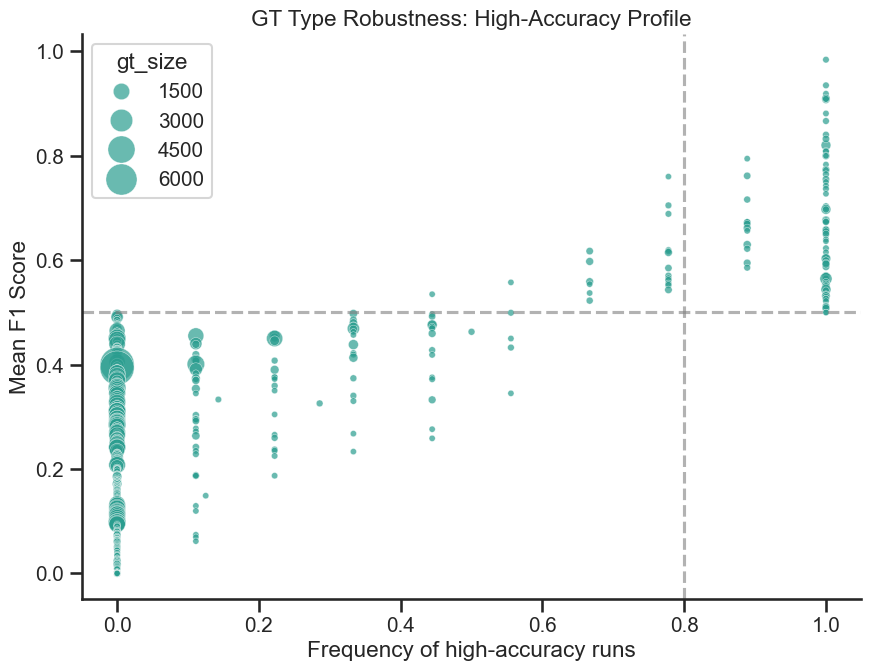

Saved: wsbm_type_summary_results\figures\low_frequency_vs_mean_score.png


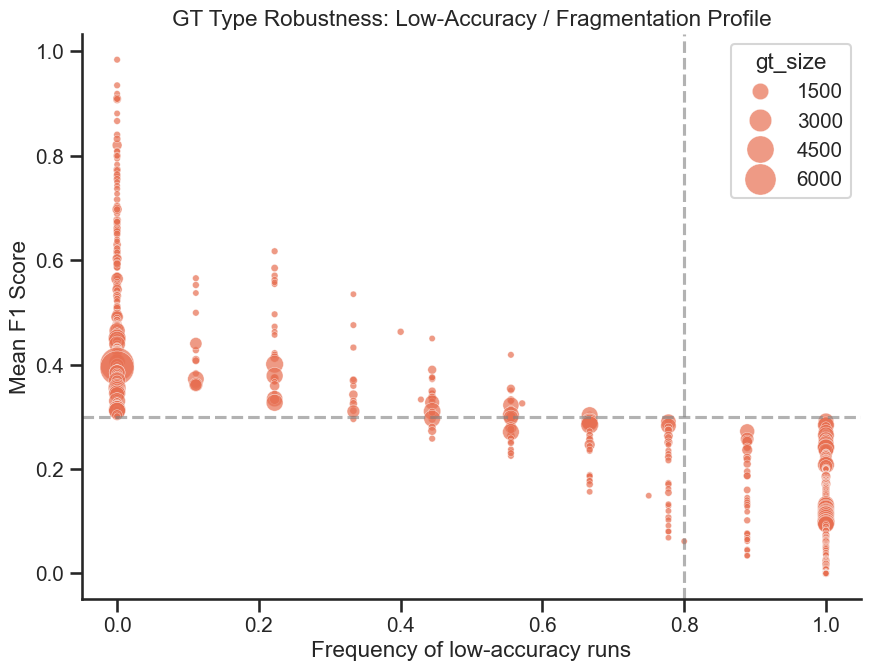

In [ ]:
n_total_runs = 10

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

def despine_if_possible():
    if HAS_SEABORN:
        sns.despine()

color_high = "#2a9d8f"
color_low = "#e76f51"

# Plot 1: high frequency vs mean score
plt.figure(figsize=(9, 7))
if HAS_SEABORN:
    sns.scatterplot(
        data=summary, x="high_frequency", y="mean_score",
        size="gt_size", sizes=(20, 600), alpha=0.7,
        color=color_high, edgecolor="white"
    )
else:
    plt.scatter(summary["high_frequency"], summary["mean_score"], s=np.sqrt(summary["gt_size"].fillna(1))*10, alpha=0.7)

plt.axhline(HIGH_THRESHOLD, color="gray", linestyle="--", alpha=0.6)
plt.axvline(ROBUST_HIGH_RUNS / n_total_runs, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("Frequency of high-accuracy runs")
plt.ylabel(f"Mean {METRIC.replace('_', ' ').title()}")
plt.title("GT Type Robustness: High-Accuracy Profile")
despine_if_possible()
savefig("high_frequency_vs_mean_score.png")

# Plot 2: low frequency vs mean score
plt.figure(figsize=(9, 7))
if HAS_SEABORN:
    sns.scatterplot(
        data=summary, x="low_frequency", y="mean_score",
        size="gt_size", sizes=(20, 600), alpha=0.7,
        color=color_low, edgecolor="white"
    )
else:
    plt.scatter(summary["low_frequency"], summary["mean_score"], s=np.sqrt(summary["gt_size"].fillna(1))*10, alpha=0.7)

plt.axhline(LOW_THRESHOLD, color="gray", linestyle="--", alpha=0.6)
plt.axvline(ROBUST_LOW_RUNS / n_total_runs, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("Frequency of low-accuracy runs")
plt.ylabel(f"Mean {METRIC.replace('_', ' ').title()}")
plt.title("GT Type Robustness: Low-Accuracy / Fragmentation Profile")
despine_if_possible()
savefig("low_frequency_vs_mean_score.png")


Saved: wsbm_type_summary_results\figures\top_robust_high_types.png


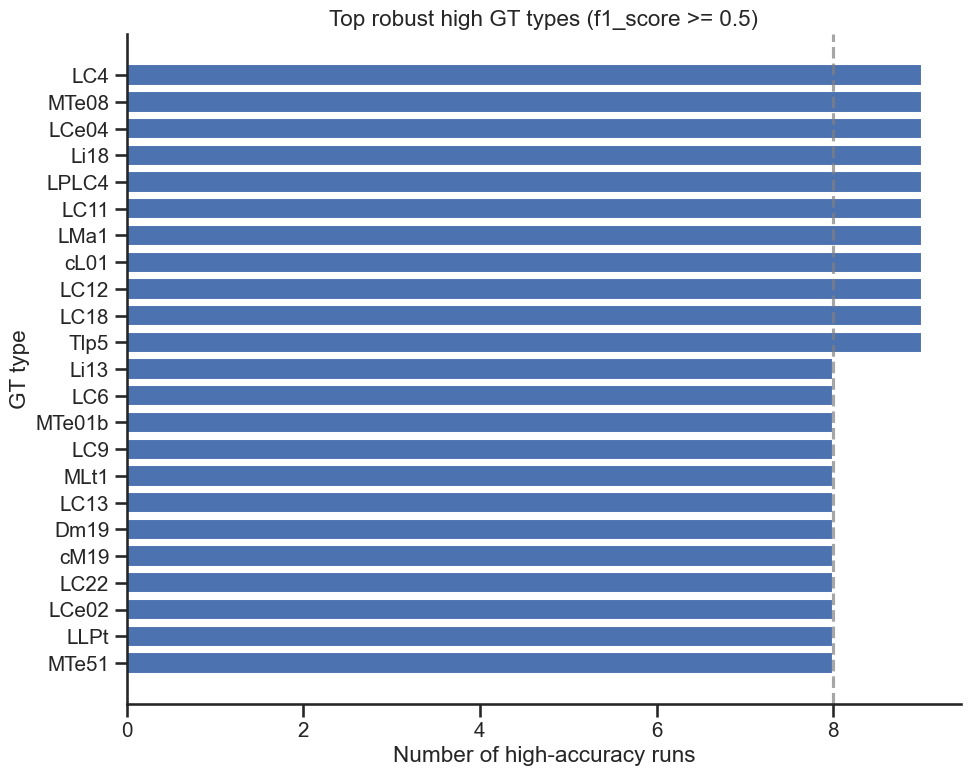

Saved: wsbm_type_summary_results\figures\top_robust_low_types.png


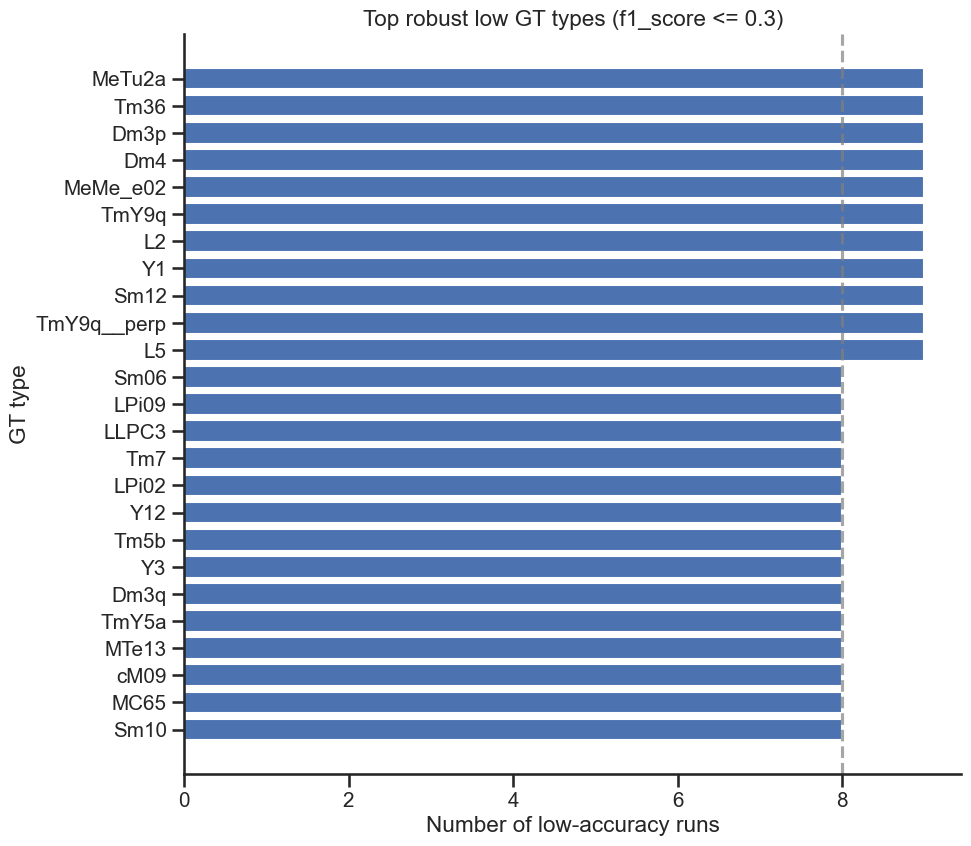

In [ ]:
# Plot 3: top robust high types
top_high = robust_high.head(TOP_N).sort_values("high_runs", ascending=True)

plt.figure(figsize=(10, max(5, 0.35 * len(top_high))))
plt.barh(top_high["gt_name"], top_high["high_runs"])
plt.axvline(ROBUST_HIGH_RUNS, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("Number of high-accuracy runs")
plt.ylabel("GT type")
plt.title(f"Top robust high GT types ({METRIC} >= {HIGH_THRESHOLD})")
despine_if_possible()
savefig("top_robust_high_types.png")

# Plot 4: top robust low types
top_low = robust_low.head(TOP_N).sort_values("low_runs", ascending=True)

plt.figure(figsize=(10, max(5, 0.35 * len(top_low))))
plt.barh(top_low["gt_name"], top_low["low_runs"])
plt.axvline(ROBUST_LOW_RUNS, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("Number of low-accuracy runs")
plt.ylabel("GT type")
plt.title(f"Top robust low GT types ({METRIC} <= {LOW_THRESHOLD})")
despine_if_possible()
savefig("top_robust_low_types.png")


## 7. Run-level consistency boxplots

Saved: wsbm_type_summary_results\figures\robust_high_score_boxplot.png


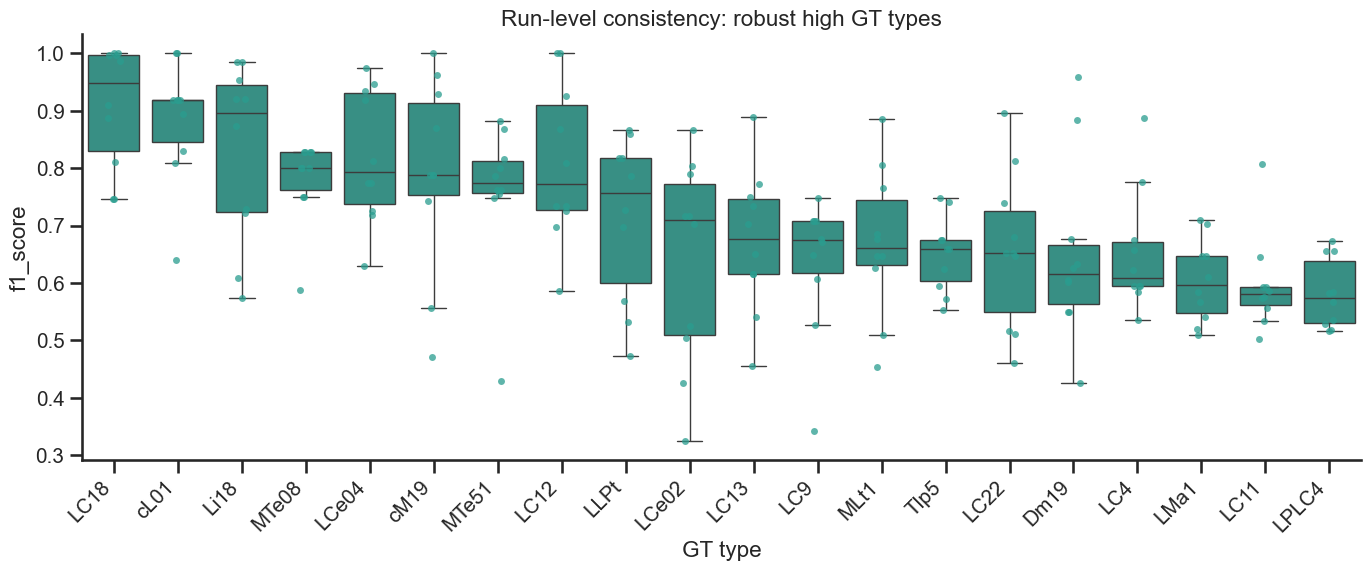

Saved: wsbm_type_summary_results\figures\robust_low_score_boxplot.png


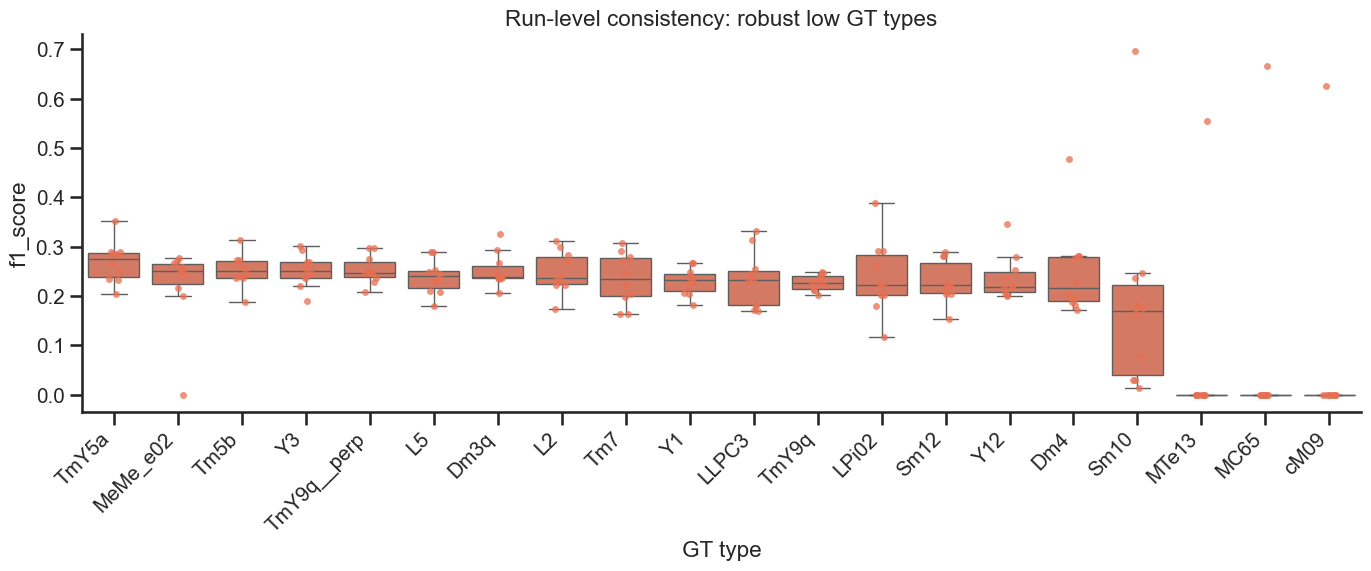

In [ ]:
selected_high_names = robust_high.head(min(20, len(robust_high)))["gt_name"].tolist()
plot_df_high = df_filtered[df_filtered["gt_name"].isin(selected_high_names)].copy()

if len(plot_df_high) > 0:
    order_high = plot_df_high.groupby("gt_name")[METRIC].median().sort_values(ascending=False).index
    plt.figure(figsize=(14, 6))
    if HAS_SEABORN:
        sns.boxplot(data=plot_df_high, x="gt_name", y=METRIC, order=order_high, color=color_high, showfliers=False)
        sns.stripplot(data=plot_df_high, x="gt_name", y=METRIC, order=order_high, color=color_high, alpha=0.75, jitter=True, size=5)
    else:
        plot_df_high.boxplot(column=METRIC, by="gt_name", rot=90)
        plt.suptitle("")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("GT type")
    plt.ylabel(METRIC)
    plt.title("Run-level consistency: robust high GT types")
    despine_if_possible()
    savefig("robust_high_score_boxplot.png")
else:
    print("No robust high types found. Skip robust_high_score_boxplot.png")

selected_low_names = robust_low.head(min(20, len(robust_low)))["gt_name"].tolist()
plot_df_low = df_filtered[df_filtered["gt_name"].isin(selected_low_names)].copy()

if len(plot_df_low) > 0:
    order_low = plot_df_low.groupby("gt_name")[METRIC].median().sort_values(ascending=False).index
    plt.figure(figsize=(14, 6))
    if HAS_SEABORN:
        sns.boxplot(data=plot_df_low, x="gt_name", y=METRIC, order=order_low, color=color_low, showfliers=False)
        sns.stripplot(data=plot_df_low, x="gt_name", y=METRIC, order=order_low, color=color_low, alpha=0.75, jitter=True, size=5)
    else:
        plot_df_low.boxplot(column=METRIC, by="gt_name", rot=90)
        plt.suptitle("")
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("GT type")
    plt.ylabel(METRIC)
    plt.title("Run-level consistency: robust low GT types")
    despine_if_possible()
    savefig("robust_low_score_boxplot.png")
else:
    print("No robust low types found. Skip robust_low_score_boxplot.png")


## 8. Run-level summary

Saved: wsbm_type_summary_results\run_level_summary.csv


,run,n_types,mean_score,median_score,high_type_count,low_type_count
0,0,355,0.272813,0.258503,53,208
1,1,352,0.277169,0.265864,57,206
2,2,352,0.277169,0.265864,57,206
3,3,350,0.280011,0.257072,54,204
4,4,352,0.293549,0.250091,64,200
5,5,356,0.310686,0.295200,79,182
6,6,356,0.280557,0.253968,56,201
7,7,356,0.297460,0.278030,63,198
8,8,356,0.285822,0.268283,53,198
9,9,354,0.298029,0.270367,66,188


Saved: wsbm_type_summary_results\figures\run_level_score_summary.png


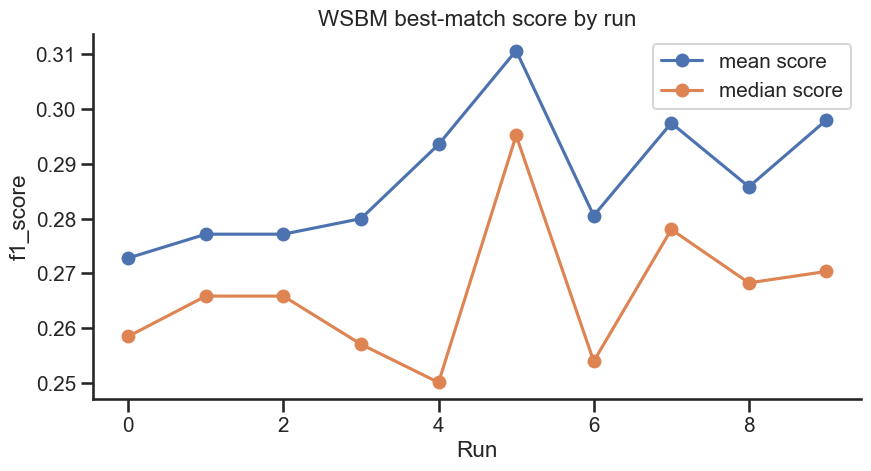

Saved: wsbm_type_summary_results\figures\run_level_high_low_counts.png


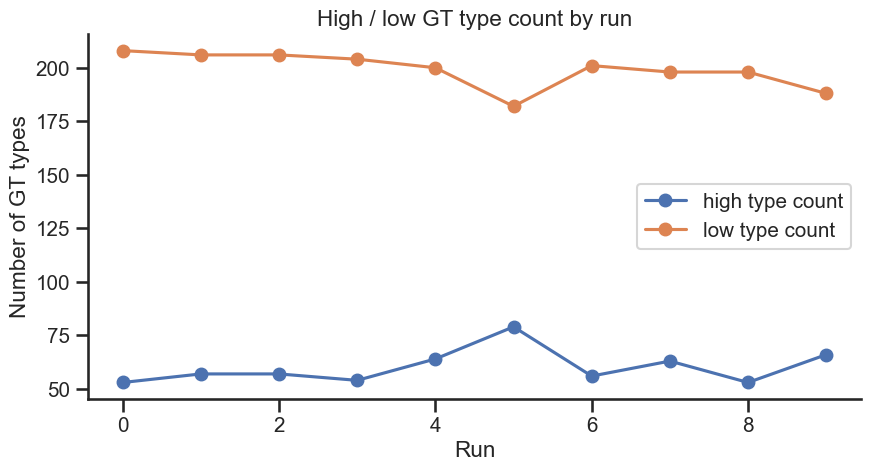

In [ ]:
run_summary = (
    df_filtered
    .groupby("run")
    .agg(
        n_types=("gt_type", "nunique"),
        mean_score=(METRIC, "mean"),
        median_score=(METRIC, "median"),
        high_type_count=("is_high", "sum"),
        low_type_count=("is_low", "sum"),
    )
    .reset_index()
)

run_summary_path = OUT_DIR / "run_level_summary.csv"
run_summary.to_csv(run_summary_path, index=False)

print(f"Saved: {run_summary_path}")
display(run_summary)

plt.figure(figsize=(9, 5))
plt.plot(run_summary["run"], run_summary["mean_score"], marker="o", label="mean score")
plt.plot(run_summary["run"], run_summary["median_score"], marker="o", label="median score")
plt.xlabel("Run")
plt.ylabel(METRIC)
plt.title("WSBM best-match score by run")
plt.legend()
despine_if_possible()
savefig("run_level_score_summary.png")

plt.figure(figsize=(9, 5))
plt.plot(run_summary["run"], run_summary["high_type_count"], marker="o", label="high type count")
plt.plot(run_summary["run"], run_summary["low_type_count"], marker="o", label="low type count")
plt.xlabel("Run")
plt.ylabel("Number of GT types")
plt.title("High / low GT type count by run")
plt.legend()
despine_if_possible()
savefig("run_level_high_low_counts.png")


## 9. Heatmap: selected GT type score across runs

Saved: wsbm_type_summary_results\figures\selected_gt_type_run_heatmap.png


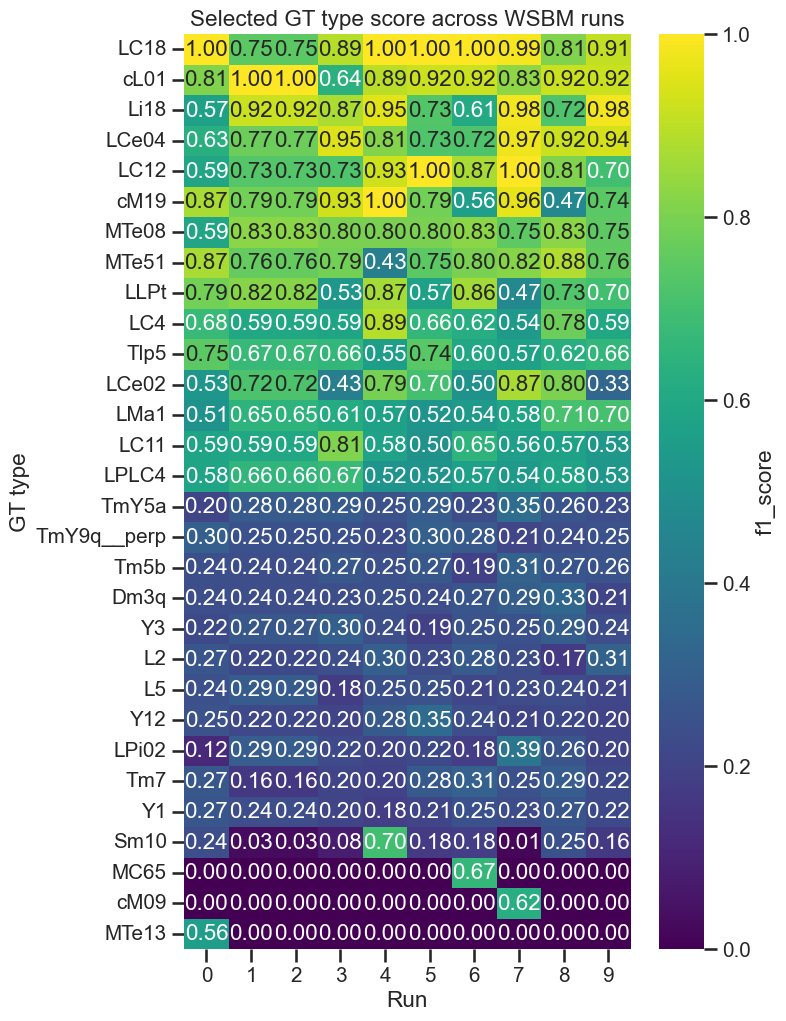

In [ ]:
heatmap_names = robust_high.head(15)["gt_name"].tolist() + robust_low.head(15)["gt_name"].tolist()
heatmap_names = list(dict.fromkeys(heatmap_names))

if len(heatmap_names) > 0:
    heat_df = (
        df_filtered[df_filtered["gt_name"].isin(heatmap_names)]
        .pivot_table(index="gt_name", columns="run", values=METRIC, aggfunc="mean")
    )
    heat_df = heat_df.loc[heat_df.mean(axis=1).sort_values(ascending=False).index]

    plt.figure(figsize=(max(8, 0.7 * n_total_runs), max(6, 0.35 * len(heat_df))))
    if HAS_SEABORN:
        sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": METRIC})
    else:
        plt.imshow(heat_df.values, aspect="auto")
        plt.xticks(range(len(heat_df.columns)), heat_df.columns)
        plt.yticks(range(len(heat_df.index)), heat_df.index)
        plt.colorbar(label=METRIC)
    plt.xlabel("Run")
    plt.ylabel("GT type")
    plt.title("Selected GT type score across WSBM runs")
    savefig("selected_gt_type_run_heatmap.png")
else:
    print("No robust high/low types found. Skip heatmap.")


## 10. Optional: neuropil distribution analysis

This part requires `root_id_type_dict.pkl` and `connections.csv.gz`.
It maps `pre_root_id` to GT type and summarizes the outgoing-synapse neuropil distribution for robust high/low types.

In [ ]:
ROOT_ID_TYPE_PATH = Path("root_id_type_dict.pkl")
CONNECTIONS_PATH = Path("connections.csv.gz")

if ROOT_ID_TYPE_PATH.exists() and CONNECTIONS_PATH.exists():
    with open(ROOT_ID_TYPE_PATH, "rb") as f:
        root_id_type_dict = pickle.load(f)

    target_high = robust_high.head(20)["gt_name"].tolist()
    target_low = robust_low.head(20)["gt_name"].tolist()

    print("Reading connections.csv.gz ...")
    df_conn = pd.read_csv(CONNECTIONS_PATH, usecols=["pre_root_id", "syn_count", "neuropil"])
    df_conn["gt_name"] = df_conn["pre_root_id"].map(root_id_type_dict)

    def compute_neuropil_distribution(target_names, label):
        tmp = df_conn[df_conn["gt_name"].isin(target_names)].copy()
        dist = tmp.groupby(["gt_name", "neuropil"])["syn_count"].sum().reset_index()

        if len(dist) == 0:
            print(f"No data for {label}")
            return pd.DataFrame(), pd.DataFrame()

        totals = dist.groupby("gt_name")["syn_count"].transform("sum")
        dist["percentage"] = 100 * dist["syn_count"] / totals

        top3 = (
            dist.sort_values(["gt_name", "syn_count"], ascending=[True, False])
            .groupby("gt_name")
            .head(3)
            .reset_index(drop=True)
        )

        wide = dist.pivot(index="gt_name", columns="neuropil", values="percentage").fillna(0)
        wide = wide.reindex([x for x in target_names if x in wide.index])

        dist.to_csv(OUT_DIR / f"{label}_neuropil_distribution_long.csv", index=False)
        top3.to_csv(OUT_DIR / f"{label}_neuropil_top3.csv", index=False)
        wide.to_csv(OUT_DIR / f"{label}_neuropil_distribution_wide.csv")

        return top3, wide

    high_top3, high_wide = compute_neuropil_distribution(target_high, "high_accuracy")
    low_top3, low_wide = compute_neuropil_distribution(target_low, "low_accuracy")

    print("\nHigh-accuracy type top neuropils:")
    display(high_top3.head(60))

    print("\nLow-accuracy type top neuropils:")
    display(low_top3.head(60))
else:
    print("Skipping neuropil analysis because root_id_type_dict.pkl or connections.csv.gz was not found.")


Reading connections.csv.gz ...

High-accuracy type top neuropils:


,gt_name,neuropil,syn_count,percentage
0,Dm19,ME_L,32655,51.405768
1,Dm19,ME_R,30867,48.591084
2,Dm19,LO_R,1,0.001574
3,LC11,PVLP_R,29741,25.886050
4,LC11,PVLP_L,27762,24.163562
5,LC11,LO_L,17395,15.140306
6,LC12,PVLP_L,73962,49.857765
7,LC12,PVLP_R,69525,46.866784
8,LC12,AVLP_R,2256,1.520769
9,LC13,PLP_L,18736,40.389756



Low-accuracy type top neuropils:


,gt_name,neuropil,syn_count,percentage
0,Dm3q,ME_R,30700,53.407094
1,Dm3q,ME_L,26778,46.584208
2,Dm3q,UNASGD,4,0.006959
3,Dm4,ME_R,52326,54.474473
4,Dm4,ME_L,43727,45.522404
5,Dm4,UNASGD,3,0.003123
6,L2,ME_R,402323,52.614351
7,L2,ME_L,354919,46.415027
8,L2,LA_R,4860,0.635573
9,L5,ME_R,317657,53.085013


Saved: wsbm_type_summary_results\figures\high_accuracy_neuropil_distribution_stacked.png


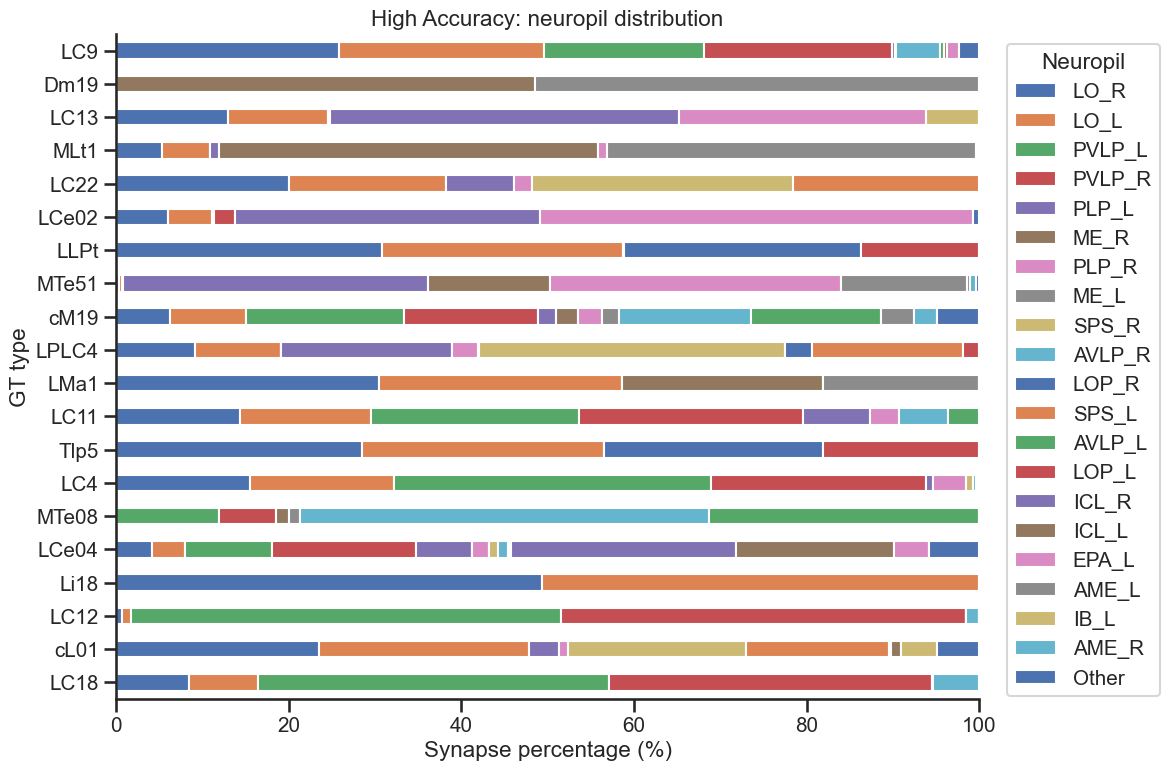

Saved: wsbm_type_summary_results\figures\low_accuracy_neuropil_distribution_stacked.png


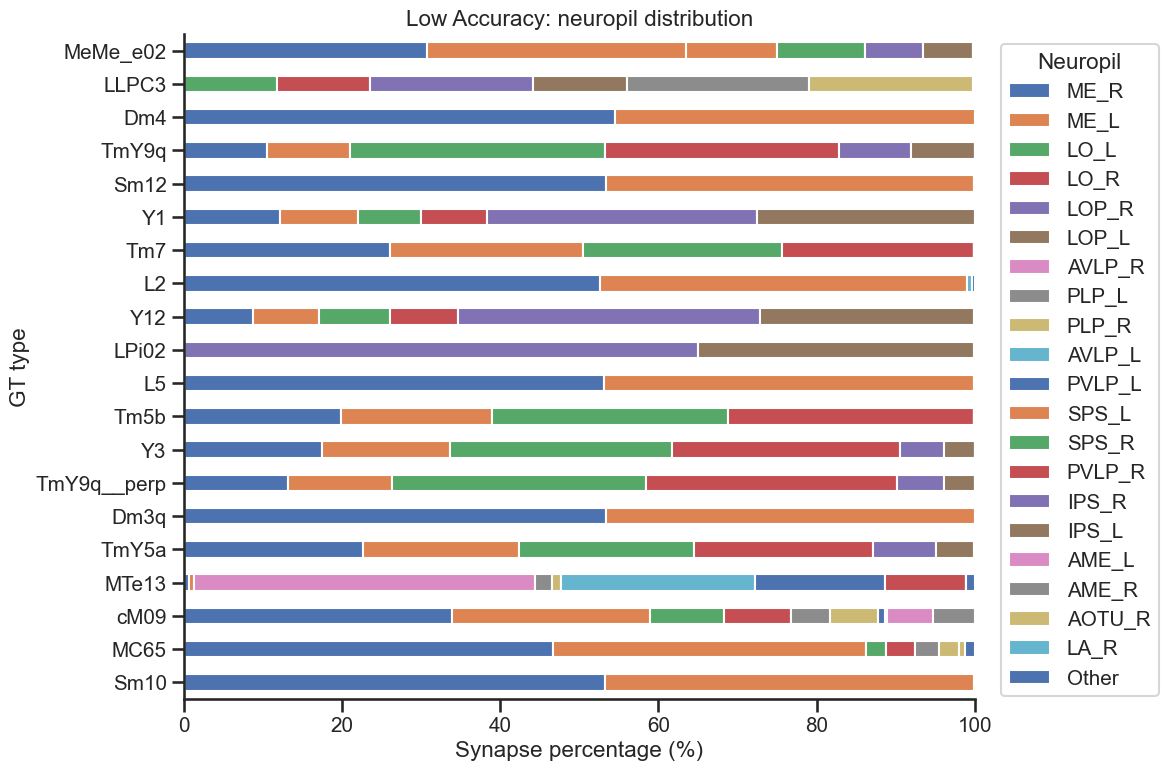

In [ ]:
def plot_neuropil_stacked_bar(wide_df, label, max_cols=20):
    if wide_df is None or len(wide_df) == 0:
        print(f"Skip {label}: empty dataframe")
        return

    top_cols = wide_df.sum(axis=0).sort_values(ascending=False).head(max_cols).index
    plot_df = wide_df[top_cols].copy()

    other = wide_df.drop(columns=top_cols, errors="ignore").sum(axis=1)
    if (other > 0).any():
        plot_df["Other"] = other

    ax = plot_df.plot(kind="barh", stacked=True, figsize=(12, max(6, 0.4 * len(plot_df))))
    ax.set_xlabel("Synapse percentage (%)")
    ax.set_ylabel("GT type")
    ax.set_title(f"{label.replace('_', ' ').title()}: neuropil distribution")
    ax.legend(title="Neuropil", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xlim(0, 100)
    despine_if_possible()
    savefig(f"{label}_neuropil_distribution_stacked.png")

if "high_wide" in globals():
    plot_neuropil_stacked_bar(high_wide, "high_accuracy")
if "low_wide" in globals():
    plot_neuropil_stacked_bar(low_wide, "low_accuracy")


## 11. Optional: aggregate neuropils into larger brain-region categories

Saved: wsbm_type_summary_results\high_accuracy_neuropil_large_categories.csv
Unmapped neuropils: []
Saved: wsbm_type_summary_results\figures\high_accuracy_large_category_heatmap.png


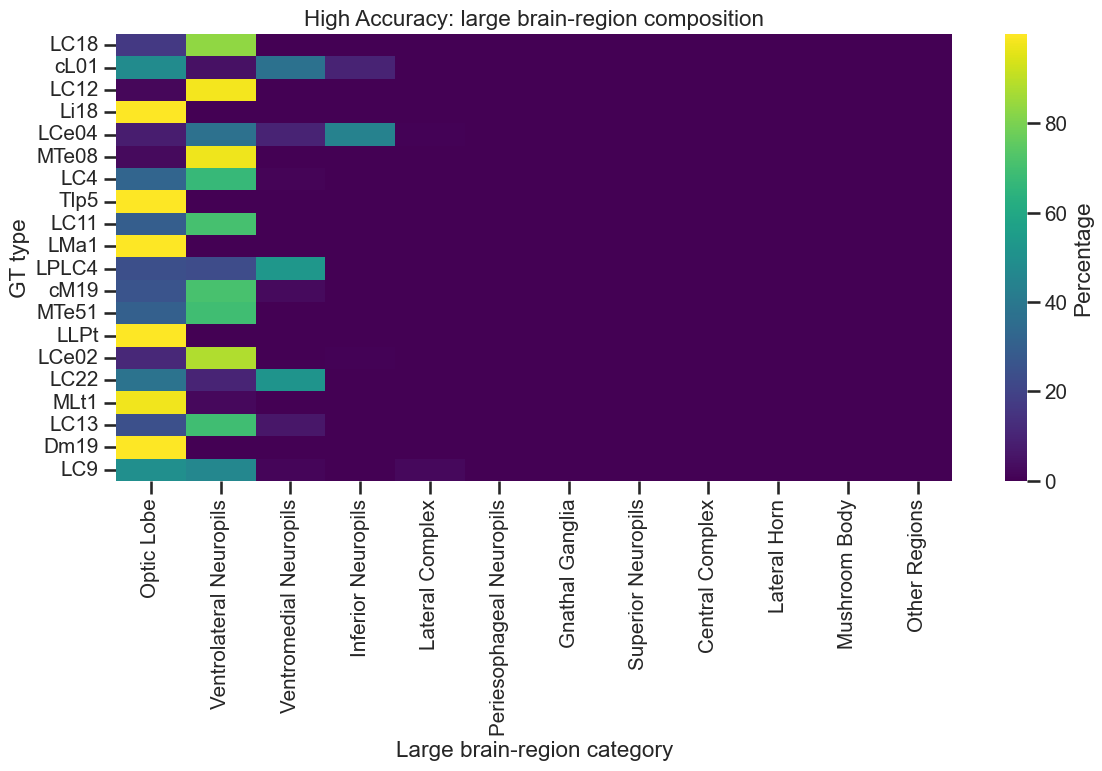

Saved: wsbm_type_summary_results\figures\high_accuracy_large_category_mean_bar.png


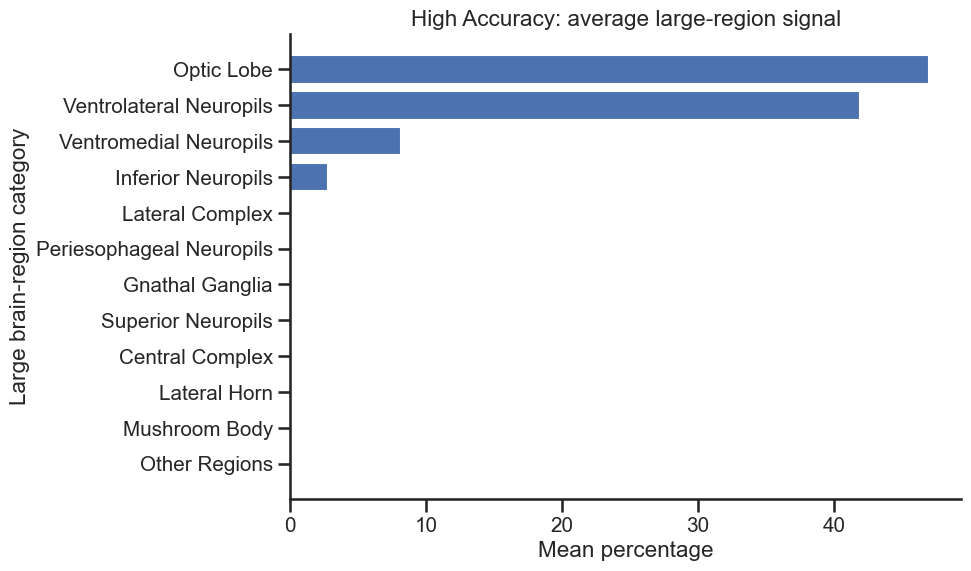

Saved: wsbm_type_summary_results\low_accuracy_neuropil_large_categories.csv
Unmapped neuropils: []
Saved: wsbm_type_summary_results\figures\low_accuracy_large_category_heatmap.png


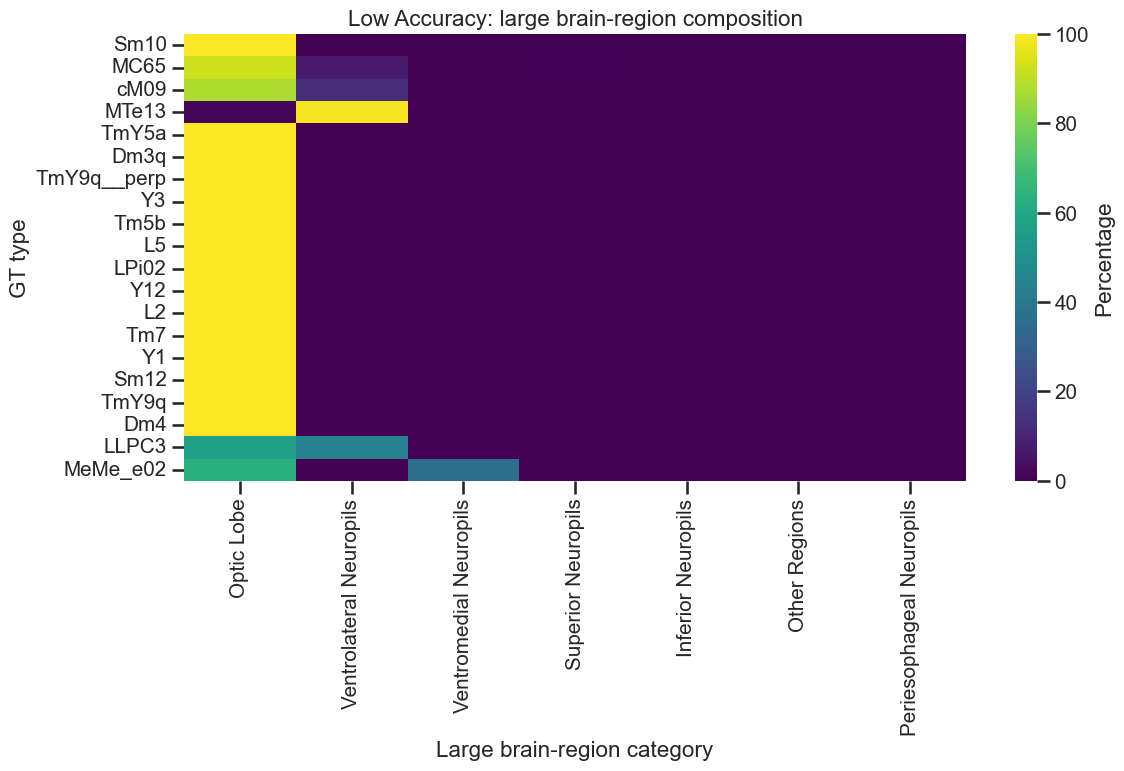

Saved: wsbm_type_summary_results\figures\low_accuracy_large_category_mean_bar.png


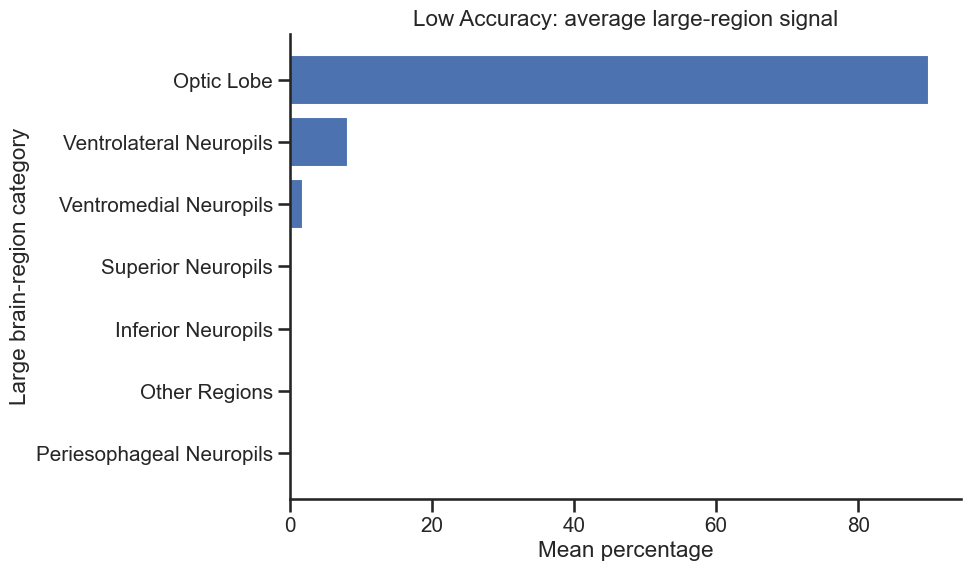

In [ ]:
category_map = {
    "AME": "Optic Lobe", "LA": "Optic Lobe", "LO": "Optic Lobe", "LOP": "Optic Lobe", "ME": "Optic Lobe",
    "BU": "Lateral Complex", "LAL": "Lateral Complex", "GA": "Lateral Complex",
    "LH": "Lateral Horn",
    "CAN": "Periesophageal Neuropils", "AMMC": "Periesophageal Neuropils", "FLA": "Periesophageal Neuropils",
    "SAD": "Periesophageal Neuropils", "PRW": "Periesophageal Neuropils",
    "ICL": "Inferior Neuropils", "IB": "Inferior Neuropils", "ATL": "Inferior Neuropils",
    "CRE": "Inferior Neuropils", "SCL": "Inferior Neuropils",
    "VES": "Ventromedial Neuropils", "GOR": "Ventromedial Neuropils", "SPS": "Ventromedial Neuropils",
    "IPS": "Ventromedial Neuropils", "EPA": "Ventromedial Neuropils",
    "MB_PED": "Mushroom Body", "MB_VL": "Mushroom Body", "MB_ML": "Mushroom Body", "MB_CA": "Mushroom Body",
    "AL": "Antennal Lobe",
    "SLP": "Superior Neuropils", "SIP": "Superior Neuropils", "SMP": "Superior Neuropils",
    "AVLP": "Ventrolateral Neuropils", "PVLP": "Ventrolateral Neuropils", "WED": "Ventrolateral Neuropils",
    "PLP": "Ventrolateral Neuropils", "AOTU": "Ventrolateral Neuropils",
    "NO": "Central Complex", "PB": "Central Complex", "EB": "Central Complex", "FB": "Central Complex",
    "GNG": "Gnathal Ganglia", "OCG": "Ocelli", "UNASGD": "Other Regions",
}

def get_base_neuropil(name):
    name = str(name)
    return name[:-2] if name.endswith(("_L", "_R")) else name

def aggregate_neuropil_categories(wide_df):
    large_df = pd.DataFrame(index=wide_df.index)
    unmapped = []

    for col in wide_df.columns:
        base = get_base_neuropil(col)
        cat = category_map.get(base)
        if cat is None:
            unmapped.append(col)
            continue
        if cat not in large_df.columns:
            large_df[cat] = 0.0
        large_df[cat] += wide_df[col]

    large_df = large_df[large_df.sum(axis=0).sort_values(ascending=False).index]
    return large_df, unmapped

def plot_large_category_analysis(wide_df, label):
    if wide_df is None or len(wide_df) == 0:
        print(f"Skip {label}: empty dataframe")
        return

    large_df, unmapped = aggregate_neuropil_categories(wide_df)
    out_csv = OUT_DIR / f"{label}_neuropil_large_categories.csv"
    large_df.to_csv(out_csv)
    print(f"Saved: {out_csv}")
    print("Unmapped neuropils:", unmapped)

    plt.figure(figsize=(12, max(5, 0.4 * len(large_df))))
    if HAS_SEABORN:
        sns.heatmap(large_df, cmap="viridis", cbar_kws={"label": "Percentage"})
    else:
        plt.imshow(large_df.values, aspect="auto")
        plt.xticks(range(len(large_df.columns)), large_df.columns, rotation=45, ha="right")
        plt.yticks(range(len(large_df.index)), large_df.index)
        plt.colorbar(label="Percentage")
    plt.xlabel("Large brain-region category")
    plt.ylabel("GT type")
    plt.title(f"{label.replace('_', ' ').title()}: large brain-region composition")
    savefig(f"{label}_large_category_heatmap.png")

    mean_vals = large_df.mean(axis=0).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(mean_vals.index, mean_vals.values)
    plt.xlabel("Mean percentage")
    plt.ylabel("Large brain-region category")
    plt.title(f"{label.replace('_', ' ').title()}: average large-region signal")
    despine_if_possible()
    savefig(f"{label}_large_category_mean_bar.png")

if "high_wide" in globals():
    plot_large_category_analysis(high_wide, "high_accuracy")
if "low_wide" in globals():
    plot_large_category_analysis(low_wide, "low_accuracy")


## 12. Large-region recognized portion analysis

This section computes the **portion** of GT types in each large brain-region category that are robustly recognized by WSBM.

It now automatically prepares `df_conn` if the optional neuropil cell has not been run yet, as long as `root_id_type_dict.pkl` and `connections.csv.gz` are available in the working directory.

Using existing `df_conn` from previous neuropil analysis cell.
Saved: wsbm_type_summary_results\gt_type_summary_with_dominant_large_region.csv
Saved: wsbm_type_summary_results\gt_type_large_region_distribution_long.csv
Saved: wsbm_type_summary_results\large_region_recognized_portion_summary.csv


,dominant_large_region,total_gt_types,robust_high_types,robust_low_types,occasionally_high_types,mean_score,median_score,mean_gt_size,total_gt_cells,robust_high_portion,robust_low_portion,occasionally_high_portion
5,Ventrolateral Neuropils,48,10,15,29,0.350420,0.332516,84.562500,8118.0,0.208333,0.312500,0.604167
6,Ventromedial Neuropils,18,3,5,13,0.274953,0.254032,23.166667,834.0,0.166667,0.277778,0.722222
0,Inferior Neuropils,8,1,2,4,0.260120,0.100000,13.375000,214.0,0.125000,0.250000,0.500000
3,Optic Lobe,277,9,98,126,0.281285,0.264538,325.237750,179206.0,0.032491,0.353791,0.454874
4,Superior Neuropils,3,0,1,4,0.469053,0.683334,7.333333,44.0,0.000000,0.333333,1.333333
1,Lateral Complex,1,0,0,1,0.356500,0.374933,27.000000,54.0,0.000000,0.000000,1.000000
2,Lateral Horn,1,0,1,0,0.066870,0.098039,12.000000,24.0,0.000000,1.000000,0.000000


Saved: wsbm_type_summary_results\figures\large_region_robust_high_type_counts.png


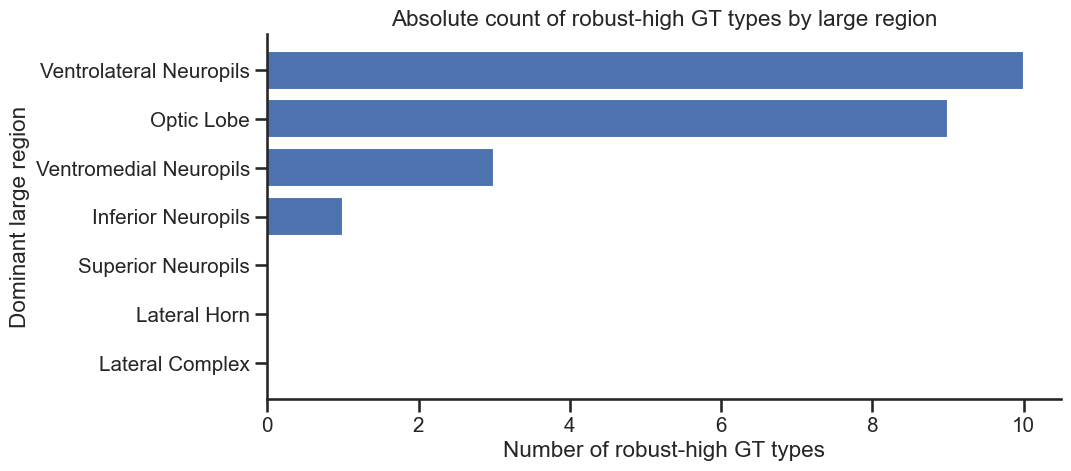

Saved: wsbm_type_summary_results\figures\large_region_robust_high_type_portion.png


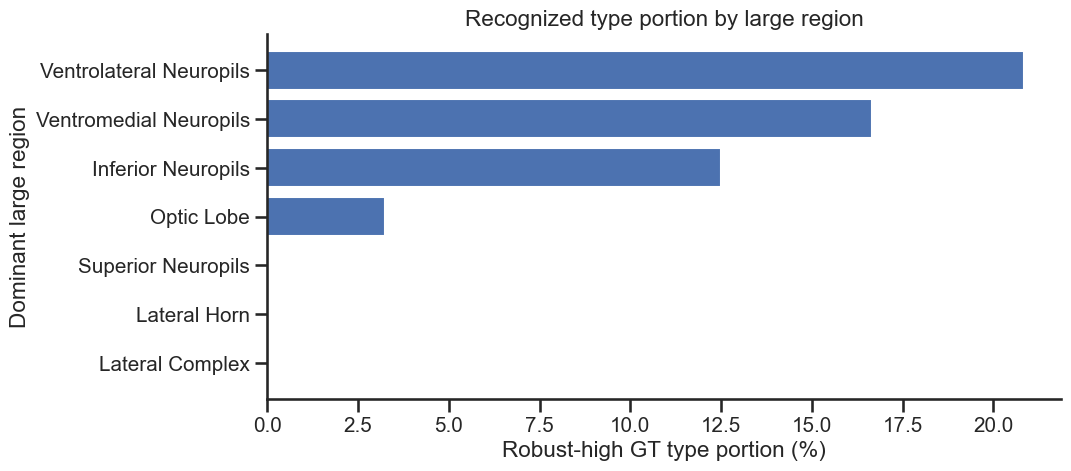

In [ ]:
# Large-region portion analysis.
# This normalizes by the number of GT types assigned to each large brain-region category.
#
# Example interpretation:
# If Optic Lobe has 200 GT types and 120 are robust_high,
# recognized_type_portion = 120 / 200 = 0.60.
#
# This cell now auto-prepares `df_conn` if it does not already exist.
# It looks for `root_id_type_dict.pkl` and `connections.csv.gz` in the current working directory.
# If you keep these files somewhere else, change ROOT_ID_TYPE_PATH and CONNECTIONS_PATH above.

def ensure_df_conn_for_region_analysis():
    """
    Make sure df_conn exists with columns:
        gt_name, neuropil, syn_count

    Priority:
    1. Use existing df_conn from optional neuropil analysis cell.
    2. If absent, load root_id_type_dict.pkl and connections.csv.gz automatically.
    3. If files are missing, return None and skip cleanly.
    """
    global df_conn, root_id_type_dict

    if "df_conn" in globals():
        needed = {"gt_name", "neuropil", "syn_count"}
        if needed.issubset(set(df_conn.columns)):
            print("Using existing `df_conn` from previous neuropil analysis cell.")
            return df_conn
        else:
            print("Existing `df_conn` does not have required columns; rebuilding it.")

    root_path = globals().get("ROOT_ID_TYPE_PATH", Path("root_id_type_dict.pkl"))
    conn_path = globals().get("CONNECTIONS_PATH", Path("connections.csv.gz"))

    root_path = Path(root_path)
    conn_path = Path(conn_path)

    if not root_path.exists() or not conn_path.exists():
        print("Skipping large-region portion analysis because required files were not found.")
        print(f"Missing root_id_type_dict.pkl? {not root_path.exists()} -> {root_path.resolve()}")
        print(f"Missing connections.csv.gz? {not conn_path.exists()} -> {conn_path.resolve()}")
        return None

    print("Preparing `df_conn` for large-region portion analysis ...")
    print(f"Loading root-id to GT-type dictionary from: {root_path}")
    with open(root_path, "rb") as f:
        root_id_type_dict = pickle.load(f)

    print(f"Reading connections from: {conn_path}")
    df_conn = pd.read_csv(conn_path, usecols=["pre_root_id", "syn_count", "neuropil"])
    df_conn["gt_name"] = df_conn["pre_root_id"].map(root_id_type_dict)

    before = len(df_conn)
    df_conn = df_conn.dropna(subset=["gt_name", "neuropil", "syn_count"]).copy()
    after = len(df_conn)
    print(f"`df_conn` ready: {after:,} rows retained out of {before:,} rows.")

    return df_conn


def build_type_large_region_table(df_conn, summary, category_map):
    tmp = df_conn[["gt_name", "neuropil", "syn_count"]].dropna(subset=["gt_name", "neuropil"]).copy()
    tmp["base_neuropil"] = tmp["neuropil"].apply(get_base_neuropil)
    tmp["large_region"] = tmp["base_neuropil"].map(category_map).fillna("Unmapped")

    # Sum outgoing synapses by GT type and large region.
    type_region = (
        tmp.groupby(["gt_name", "large_region"])["syn_count"]
        .sum()
        .reset_index()
    )

    type_total = type_region.groupby("gt_name")["syn_count"].transform("sum")
    type_region["region_percentage"] = 100 * type_region["syn_count"] / type_total

    # Assign each GT type to the dominant large region.
    dominant_region = (
        type_region
        .sort_values(["gt_name", "syn_count"], ascending=[True, False])
        .groupby("gt_name")
        .head(1)
        .rename(columns={
            "large_region": "dominant_large_region",
            "syn_count": "dominant_region_syn_count",
            "region_percentage": "dominant_region_percentage",
        })
        [["gt_name", "dominant_large_region", "dominant_region_syn_count", "dominant_region_percentage"]]
    )

    # Merge with WSBM summary.
    type_region_summary = summary.merge(dominant_region, on="gt_name", how="left")
    type_region_summary["dominant_large_region"] = type_region_summary["dominant_large_region"].fillna("Unknown")

    return type_region_summary, type_region


df_conn_for_region = ensure_df_conn_for_region_analysis()

if df_conn_for_region is not None:
    type_region_summary, type_region_long = build_type_large_region_table(
        df_conn_for_region, summary, category_map
    )

    type_region_summary_path = OUT_DIR / "gt_type_summary_with_dominant_large_region.csv"
    type_region_long_path = OUT_DIR / "gt_type_large_region_distribution_long.csv"
    type_region_summary.to_csv(type_region_summary_path, index=False)
    type_region_long.to_csv(type_region_long_path, index=False)

    print(f"Saved: {type_region_summary_path}")
    print(f"Saved: {type_region_long_path}")

    region_portion_summary = (
        type_region_summary
        .groupby("dominant_large_region")
        .agg(
            total_gt_types=("gt_name", "nunique"),
            robust_high_types=("category", lambda x: (x == "robust_high").sum()),
            robust_low_types=("category", lambda x: (x == "robust_low").sum()),
            occasionally_high_types=("category", lambda x: (x == "occasionally_high").sum()),
            mean_score=("mean_score", "mean"),
            median_score=("median_score", "median"),
            mean_gt_size=("gt_size", "mean"),
            total_gt_cells=("gt_size", "sum"),
        )
        .reset_index()
    )

    region_portion_summary["robust_high_portion"] = (
        region_portion_summary["robust_high_types"] / region_portion_summary["total_gt_types"]
    )
    region_portion_summary["robust_low_portion"] = (
        region_portion_summary["robust_low_types"] / region_portion_summary["total_gt_types"]
    )
    region_portion_summary["occasionally_high_portion"] = (
        region_portion_summary["occasionally_high_types"] / region_portion_summary["total_gt_types"]
    )

    # Sort by robust_high_portion first, then by robust_high_types.
    region_portion_summary = region_portion_summary.sort_values(
        ["robust_high_portion", "robust_high_types", "total_gt_types"],
        ascending=[False, False, False]
    )

    region_portion_path = OUT_DIR / "large_region_recognized_portion_summary.csv"
    region_portion_summary.to_csv(region_portion_path, index=False)
    print(f"Saved: {region_portion_path}")

    display(region_portion_summary)

    # Count plot: absolute number of robust-high types.
    plot_df = region_portion_summary.sort_values("robust_high_types", ascending=True)
    plt.figure(figsize=(11, max(5, 0.45 * len(plot_df))))
    plt.barh(plot_df["dominant_large_region"], plot_df["robust_high_types"])
    plt.xlabel("Number of robust-high GT types")
    plt.ylabel("Dominant large region")
    plt.title("Absolute count of robust-high GT types by large region")
    despine_if_possible()
    savefig("large_region_robust_high_type_counts.png")

    # Portion plot: normalized by total number of GT types in each region.
    plot_df = region_portion_summary.sort_values("robust_high_portion", ascending=True)
    plt.figure(figsize=(11, max(5, 0.45 * len(plot_df))))
    plt.barh(plot_df["dominant_large_region"], 100 * plot_df["robust_high_portion"])
    plt.xlabel("Robust-high GT type portion (%)")
    plt.ylabel("Dominant large region")
    plt.title("Recognized type portion by large region")
    despine_if_possible()
    savefig("large_region_robust_high_type_portion.png")


## Output

CSV outputs are saved under `wsbm_type_summary_results/`.

Main summary outputs:
- `gt_type_accuracy_summary.csv`
- `robust_high_types.csv`
- `robust_low_types.csv`
- `always_high_types.csv`
- `always_low_types.csv`
- `occasionally_high_types.csv`
- `mixed_types_high_and_low.csv`
- `large_region_recognized_portion_summary.csv`

Figures are saved under `wsbm_type_summary_results/figures/`.
